Numeric-only shape: (6378, 7)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70
5,19,88,8,89,3,3,71
6,29,84,7,68,1,2,67
7,25,78,6,50,1,2,66
8,17,94,6,80,0,1,69
9,23,98,8,71,0,5,72


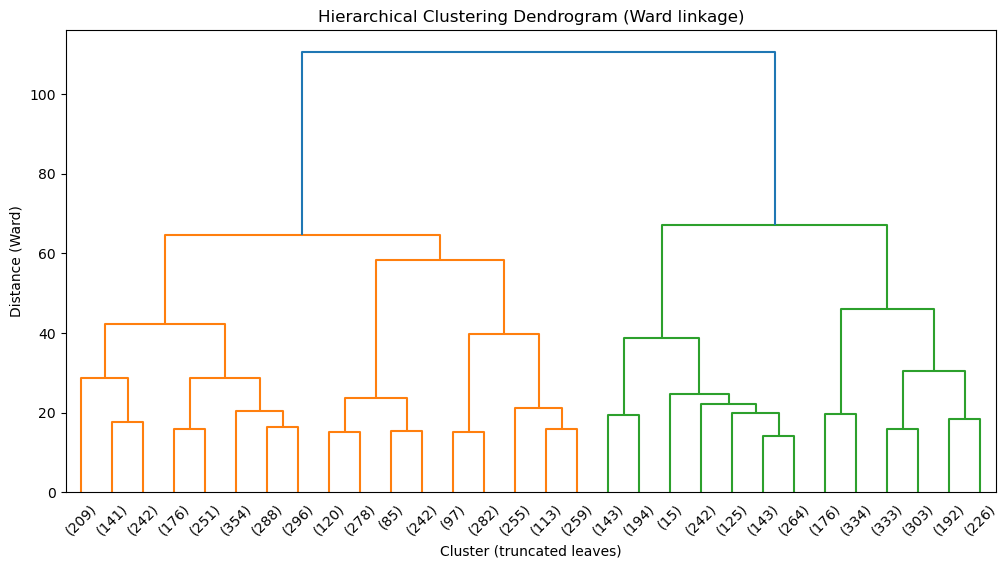


Hierarchical cluster counts (k=2):
{np.int32(1): np.int64(3688), np.int32(2): np.int64(2690)}


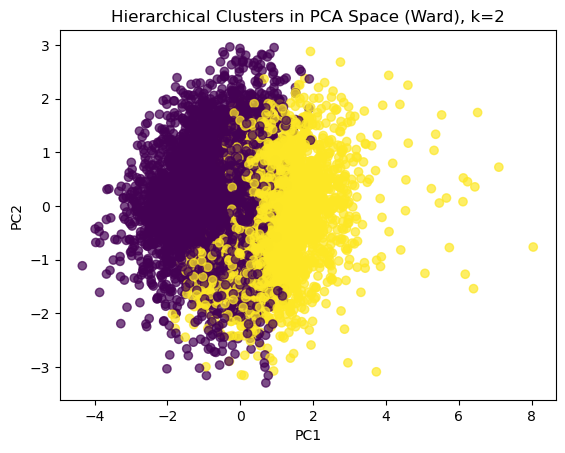


Hierarchical cluster counts (k=3):
{np.int32(1): np.int64(3688), np.int32(2): np.int64(1126), np.int32(3): np.int64(1564)}


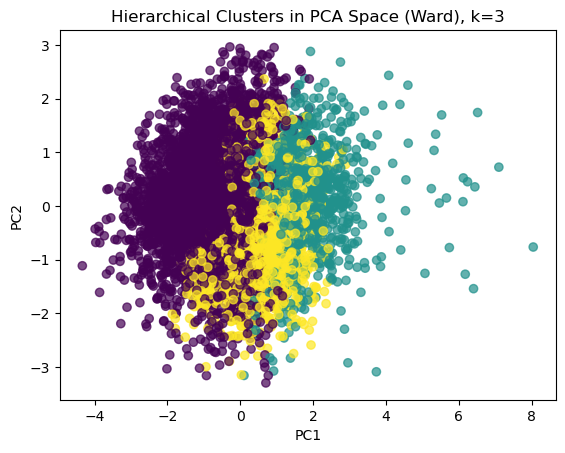


Hierarchical cluster counts (k=5):
{np.int32(1): np.int64(1957), np.int32(2): np.int64(725), np.int32(3): np.int64(1006), np.int32(4): np.int64(1126), np.int32(5): np.int64(1564)}


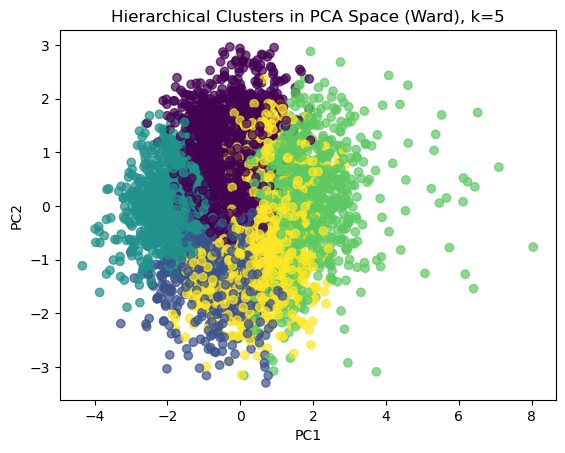

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Load + clean numeric data 

path = (r"C:\Users\User\Machine\Jupyter file\dataset1_raw.csv")
raw_df = pd.read_csv(path).dropna()

LABEL_COLS = []  # if we have a label column, put it here
DROP_COLS = ["id", "gender", "occupation_type"]  # drop qualitative columns

df_work = raw_df.copy()
label_present = [c for c in LABEL_COLS if c in df_work.columns]
if label_present:
    df_work = df_work.drop(columns=label_present)

drop_present = [c for c in DROP_COLS if c in df_work.columns]
df_work = df_work.drop(columns=drop_present)

df_numeric = df_work.select_dtypes(include=[np.number]).copy()

print("Numeric-only shape:", df_numeric.shape)
display(df_numeric.head(10))

SAVED_DATASET_PATH = (r"C:\Users\User\Machine\Jupyter file\dataset1_hierarchical_clean.csv")
df_numeric.to_csv(SAVED_DATASET_PATH, index=False)


# Normalize

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# PCA to 3 components for clustering comparability
# This makes it directly comparable to our KMeans that ran on PC1-3.

pca3 = PCA(n_components=3, random_state=42)
Z3 = pca3.fit_transform(X_scaled)

# Hierarchical clustering (Agglomerative) + Dendrogram
# Ward linkage is common and tends to create compact clusters.
# linkage matrix encodes the merges
# method="ward" requires Euclidean distance; "metric" param in scipy depends on version

Z_link = linkage(Z3, method="ward")  # clustering performed on PCA-3 space

# Plot dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z_link, truncate_mode = "lastp", p=30, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Cluster (truncated leaves)")
plt.ylabel("Distance (Ward)")
plt.show()

# If we want the full dendrogram (can be huge):
# plt.figure(figsize=(14, 6))
# dendrogram(Z_link)
# plt.show()

# Choose a number of clusters from dendrogram cut
#    Example: cut into k clusters (pick k that match our top KMeans values)

top_Kvalues = [2, 3, 5]


for k in top_Kvalues:
    hc_labels = fcluster(Z_link, t=k, criterion="maxclust")
    
    print("\nHierarchical cluster counts (k={}):".format(k))
    unique, counts = np.unique(hc_labels, return_counts=True)
    print(dict(zip(unique, counts)))

# Visualize hierarchical clusters in PCA space (PC1 vs PC2)
    plt.figure()
    plt.scatter(Z3[:, 0], Z3[:, 1], c=hc_labels, alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Hierarchical Clusters in PCA Space (Ward), k={k}")
    plt.show()